In [1]:
# ============================================================
# CELL 1: Imports, Reproducibility, GPU Setup, File Upload
# Case I (CORRECTED): Inverse PINN for Fisher-KPP — D Unknown, r Known
# ============================================================

import os
import copy
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

torch.set_default_dtype(torch.float32)

from google.colab import files

DATA_FILENAME = "FisherKPP_Inverse_PINN_Dataset.csv"   # Dataset 1: D_true=0.01, r_true=1.0
DATA_PATH = f"/content/{DATA_FILENAME}"

if not os.path.exists(DATA_PATH):
    print(f"Please upload: {DATA_FILENAME}")
    uploaded = files.upload()
    uploaded_name = list(uploaded.keys())[0]
    if uploaded_name != DATA_FILENAME:
        os.rename(uploaded_name, DATA_PATH)
else:
    print(f"Found existing file at {DATA_PATH}")

print("Setup complete.")

Using device: cuda
GPU: Tesla T4
Please upload: FisherKPP_Inverse_PINN_Dataset.csv


Saving FisherKPP_Inverse_PINN_Dataset.csv to FisherKPP_Inverse_PINN_Dataset.csv
Setup complete.


Raw data shape: (321600, 3)
       x    t         u
0  0.000  0.0  0.000000
1  0.005  0.0  0.000005
2  0.010  0.0  0.000006
3  0.015  0.0  0.000008
4  0.020  0.0  0.000010
Detected grid: Nx=201, Nt=1600

Max |FDM IC - Analytical IC| at t=0: 3.727e-06  (should be ~1e-6)
Max |u(0,t)|: 0.000e+00
Max |u(1,t)|: 0.000e+00


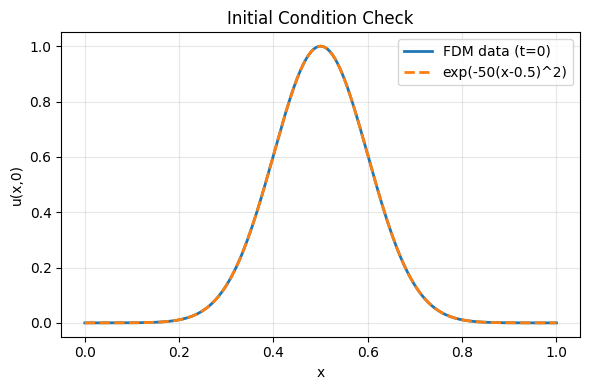

In [2]:
# ============================================================
# CELL 2: Load Dataset, Reshape to Grid, Verify IC/BC
# ============================================================

df = pd.read_csv(DATA_PATH)
print("Raw data shape:", df.shape)
print(df.head())

x_grid = np.sort(df["x"].unique())
t_grid = np.sort(df["t"].unique())
Nx = len(x_grid)
Nt = len(t_grid)
print(f"Detected grid: Nx={Nx}, Nt={Nt}")

df_sorted = df.sort_values(by=["t", "x"]).reset_index(drop=True)
U_grid = df_sorted["u"].values.reshape(Nt, Nx)

u_ic_fdm = U_grid[0, :]
u_ic_analytical = np.exp(-50 * (x_grid - 0.5)**2)
ic_max_diff = np.max(np.abs(u_ic_fdm - u_ic_analytical))
print(f"\nMax |FDM IC - Analytical IC| at t=0: {ic_max_diff:.3e}  (should be ~1e-6)")

print(f"Max |u(0,t)|: {np.max(np.abs(U_grid[:, 0])):.3e}")
print(f"Max |u(1,t)|: {np.max(np.abs(U_grid[:, -1])):.3e}")

plt.figure(figsize=(6, 4))
plt.plot(x_grid, u_ic_fdm, label="FDM data (t=0)", lw=2)
plt.plot(x_grid, u_ic_analytical, "--", label="exp(-50(x-0.5)^2)", lw=2)
plt.xlabel("x"); plt.ylabel("u(x,0)")
plt.title("Initial Condition Check")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
# ============================================================
# CELL 3: Prepare Training Data (CORRECTED: N_bc=200, linspace IC)
# ============================================================

N_data = 10000
data_sample = df.sample(n=N_data, random_state=42).reset_index(drop=True)

X_data = data_sample[["x", "t"]].values
U_data = data_sample[["u"]].values

X_train, X_val, U_train, U_val = train_test_split(
    X_data, U_data, test_size=0.20, random_state=42
)

x_train_t = torch.tensor(X_train[:, 0:1], dtype=torch.float32, device=device)
t_train_t = torch.tensor(X_train[:, 1:2], dtype=torch.float32, device=device)
u_train_t = torch.tensor(U_train, dtype=torch.float32, device=device)

x_val_t = torch.tensor(X_val[:, 0:1], dtype=torch.float32, device=device)
t_val_t = torch.tensor(X_val[:, 1:2], dtype=torch.float32, device=device)
u_val_t = torch.tensor(U_val, dtype=torch.float32, device=device)

print(f"Training data points:   {x_train_t.shape[0]}")
print(f"Validation data points: {x_val_t.shape[0]}")

# Collocation points
N_f = 10000
np.random.seed(42)
x_f = np.random.uniform(0, 1, (N_f, 1))
t_f = np.random.uniform(1e-4, 1, (N_f, 1))
x_f_t = torch.tensor(x_f, dtype=torch.float32, device=device, requires_grad=True)
t_f_t = torch.tensor(t_f, dtype=torch.float32, device=device, requires_grad=True)
print(f"Collocation points: {x_f_t.shape[0]}")

# IC points -- CORRECTED: deterministic linspace, not random
N_ic = 200
x_ic = np.linspace(0, 1, N_ic).reshape(-1, 1)
t_ic = np.zeros_like(x_ic)
u_ic_target = np.exp(-50 * (x_ic - 0.5)**2)
x_ic_t = torch.tensor(x_ic, dtype=torch.float32, device=device)
t_ic_t = torch.tensor(t_ic, dtype=torch.float32, device=device)
u_ic_target_t = torch.tensor(u_ic_target, dtype=torch.float32, device=device)
print(f"IC points: {x_ic_t.shape[0]} (deterministic linspace)")

# BC points -- CORRECTED: N_bc=200 (was 10000)
N_bc = 200
np.random.seed(42)
t_bc = np.random.uniform(0, 1, (N_bc, 1))
x_left_t = torch.tensor(np.zeros_like(t_bc), dtype=torch.float32, device=device)
x_right_t = torch.tensor(np.ones_like(t_bc), dtype=torch.float32, device=device)
t_bc_t = torch.tensor(t_bc, dtype=torch.float32, device=device)
u_bc_target_t = torch.zeros((N_bc, 1), dtype=torch.float32, device=device)
print(f"BC points: {N_bc} (left) + {N_bc} (right)  [corrected from 10000]")

print("\nAll training tensors prepared on device:", device)

Training data points:   8000
Validation data points: 2000
Collocation points: 10000
IC points: 200 (deterministic linspace)
BC points: 200 (left) + 200 (right)  [corrected from 10000]

All training tensors prepared on device: cuda


In [4]:
# ============================================================
# CELL 4: PINN Architecture — D Unknown, r Fixed (=1.0)
# ============================================================

class PINN_D(nn.Module):
    """
    Inverse PINN for Fisher-KPP, D unknown, r fixed.
    u_t = D*u_xx + r_fixed*u*(1-u)
    D = exp(logD), guaranteed positive.
    """
    def __init__(self, layers=[2, 50, 50, 50, 50, 50, 50, 50, 1], logD_init=-4.0):
        super(PINN_D, self).__init__()

        self.linears = nn.ModuleList(
            [nn.Linear(layers[i], layers[i+1]) for i in range(len(layers) - 1)]
        )
        self.activation = nn.Tanh()

        for layer in self.linears:
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)

        self.logD = nn.Parameter(torch.tensor([logD_init], dtype=torch.float32))

    @property
    def D(self):
        return torch.exp(self.logD)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        out = inp
        for i, layer in enumerate(self.linears):
            out = layer(out)
            if i < len(self.linears) - 1:
                out = self.activation(out)
        return out


r_fixed = 1.0   # known/fixed for Dataset 1

model = PINN_D(layers=[2, 50, 50, 50, 50, 50, 50, 50, 1], logD_init=-4.0).to(device)

print(model)
print(f"\nInitial D = {model.D.item():.6f}  (true D = 0.01)")
print(f"Fixed r = {r_fixed}  (known)")
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters())}")

PINN_D(
  (linears): ModuleList(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1-6): 6 x Linear(in_features=50, out_features=50, bias=True)
    (7): Linear(in_features=50, out_features=1, bias=True)
  )
  (activation): Tanh()
)

Initial D = 0.018316  (true D = 0.01)
Fixed r = 1.0  (known)
Total trainable parameters: 15502


In [5]:
# ============================================================
# CELL 5: Derivative Computation and PDE Residual
# ============================================================

def compute_derivatives(model, x, t):
    u = model(x, t)

    u_t = torch.autograd.grad(
        u, t, grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]

    u_x = torch.autograd.grad(
        u, x, grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x, x, grad_outputs=torch.ones_like(u_x),
        create_graph=True, retain_graph=True
    )[0]

    return u, u_t, u_x, u_xx


def pde_residual(model, x, t, r=1.0):
    """
    Fisher-KPP residual: D unknown (from model), r fixed/known.
    f = u_t - D*u_xx - r*u*(1-u)
    """
    u, u_t, u_x, u_xx = compute_derivatives(model, x, t)
    D = model.D
    f = u_t - D * u_xx - r * u * (1 - u)
    return f


print("Derivative and PDE residual functions defined.")

test_f = pde_residual(model, x_f_t[:5], t_f_t[:5], r=r_fixed)
print("Sample PDE residual shape:", test_f.shape)
print("Sample PDE residual values:", test_f.detach().cpu().numpy().flatten())

Derivative and PDE residual functions defined.
Sample PDE residual shape: torch.Size([5, 1])
Sample PDE residual values: [0.10714086 0.3239332  0.22572842 0.23035435 0.02483653]


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [6]:
# ============================================================
# CELL 6: Loss Functions
# ============================================================

mse = nn.MSELoss()

def loss_data(model, x, t, u_true):
    u_pred = model(x, t)
    return mse(u_pred, u_true)

def loss_pde(model, x_f, t_f, r=1.0):
    f = pde_residual(model, x_f, t_f, r=r)
    return mse(f, torch.zeros_like(f))

def loss_ic(model, x_ic, t_ic, u_ic_target):
    u_pred = model(x_ic, t_ic)
    return mse(u_pred, u_ic_target)

def loss_bc(model, x_left, x_right, t_bc, u_bc_target):
    u_left_pred = model(x_left, t_bc)
    u_right_pred = model(x_right, t_bc)
    return mse(u_left_pred, u_bc_target) + mse(u_right_pred, u_bc_target)


def total_loss(model, x_data, t_data, u_data,
               x_f, t_f,
               x_ic, t_ic, u_ic_target,
               x_left, x_right, t_bc, u_bc_target,
               r=1.0, w_data=100.0, w_pde=1.0, w_ic=10.0, w_bc=10.0):
    L_data = loss_data(model, x_data, t_data, u_data)
    L_pde  = loss_pde(model, x_f, t_f, r=r)
    L_ic   = loss_ic(model, x_ic, t_ic, u_ic_target)
    L_bc   = loss_bc(model, x_left, x_right, t_bc, u_bc_target)

    L_total = w_data * L_data + w_pde * L_pde + w_ic * L_ic + w_bc * L_bc
    return L_total, L_data, L_pde, L_ic, L_bc


print("Loss functions defined.")

Loss functions defined.


In [7]:
# ============================================================
# CELL 7: Optimizer — Two Parameter Groups
# ============================================================

network_params = []
for layer in model.linears:
    network_params += list(layer.parameters())

optimizer = torch.optim.Adam([
    {"params": network_params, "lr": 1e-3},
    {"params": [model.logD], "lr": 5e-4}
])

print("Optimizer parameter groups (Case I corrected: D-only recovery):")
for i, g in enumerate(optimizer.param_groups):
    n_params = sum(p.numel() for p in g["params"])
    print(f"  Group {i}: lr={g['lr']}, num_params={n_params}")

Optimizer parameter groups (Case I corrected: D-only recovery):
  Group 0: lr=0.001, num_params=15501
  Group 1: lr=0.0005, num_params=1


In [8]:
# ============================================================
# CELL 8: Training Loop — D Recovery (CORRECTED: Full Weighted Val Loss)
# ============================================================

EPOCHS = 12000
PATIENCE = 2000
MIN_DELTA = 1e-8
D_true = 0.01

history = {
    "train_total": [], "train_data": [], "train_pde": [], "train_ic": [], "train_bc": [],
    "val_total": [], "D": [], "D_error_pct": []
}

best_val_loss = float("inf")
best_epoch = -1
best_model_state = None
patience_counter = 0

start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()

    L_total, L_data, L_pde, L_ic, L_bc = total_loss(
        model,
        x_train_t, t_train_t, u_train_t,
        x_f_t, t_f_t,
        x_ic_t, t_ic_t, u_ic_target_t,
        x_left_t, x_right_t, t_bc_t, u_bc_target_t,
        r=r_fixed
    )
    L_total.backward()
    optimizer.step()

    # VALIDATION: full weighted loss (CORRECTED from plain L_data)
    model.eval()
    Lv_total, Lv_data, Lv_pde, Lv_ic, Lv_bc = total_loss(
        model,
        x_val_t, t_val_t, u_val_t,
        x_f_t, t_f_t,
        x_ic_t, t_ic_t, u_ic_target_t,
        x_left_t, x_right_t, t_bc_t, u_bc_target_t,
        r=r_fixed
    )

    D_current = model.D.item()
    D_err_pct = abs(D_current - D_true) / D_true * 100.0

    history["train_total"].append(L_total.item())
    history["train_data"].append(L_data.item())
    history["train_pde"].append(L_pde.item())
    history["train_ic"].append(L_ic.item())
    history["train_bc"].append(L_bc.item())
    history["val_total"].append(Lv_total.item())
    history["D"].append(D_current)
    history["D_error_pct"].append(D_err_pct)

    current_val = Lv_total.item()
    if current_val < best_val_loss - MIN_DELTA:
        best_val_loss = current_val
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 500 == 0 or epoch == 0:
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1:5d}/{EPOCHS} | "
              f"Train: {L_total.item():.4e} | Val: {current_val:.4e} | "
              f"D={D_current:.6f} (err {D_err_pct:.3f}%) | "
              f"Patience {patience_counter}/{PATIENCE} | {elapsed:.1f}s")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}. "
              f"Best epoch: {best_epoch+1} with val loss {best_val_loss:.6e}")
        break

total_time = time.time() - start_time
print(f"\nTraining finished in {total_time:.1f}s ({epoch+1} epochs run)")

model.load_state_dict(best_model_state)
model.eval()

D_final = model.D.item()
print(f"\nBest model restored from epoch {best_epoch+1}")
print(f"Recovered D = {D_final:.6f}  (true D = {D_true}) -> error {abs(D_final-D_true)/D_true*100:.4f}%")

Epoch     1/12000 | Train: 3.7706e+01 | Val: 1.6081e+01 | D=0.018325 (err 83.248%) | Patience 0/2000 | 0.7s
Epoch   500/12000 | Train: 1.8671e-02 | Val: 1.8675e-02 | D=0.014904 (err 49.035%) | Patience 0/2000 | 17.7s
Epoch  1000/12000 | Train: 9.2241e-03 | Val: 1.0371e-02 | D=0.013124 (err 31.237%) | Patience 13/2000 | 31.3s
Epoch  1500/12000 | Train: 3.0982e-02 | Val: 5.8373e-02 | D=0.011943 (err 19.434%) | Patience 27/2000 | 44.4s
Epoch  2000/12000 | Train: 2.9402e-03 | Val: 3.8217e-03 | D=0.011148 (err 11.484%) | Patience 12/2000 | 57.7s
Epoch  2500/12000 | Train: 9.4630e-04 | Val: 9.3015e-04 | D=0.010624 (err 6.245%) | Patience 0/2000 | 70.9s
Epoch  3000/12000 | Train: 1.5051e-03 | Val: 1.0086e-03 | D=0.010290 (err 2.901%) | Patience 60/2000 | 83.9s
Epoch  3500/12000 | Train: 7.2956e-04 | Val: 1.8228e-03 | D=0.010093 (err 0.930%) | Patience 67/2000 | 97.5s
Epoch  4000/12000 | Train: 1.1526e-03 | Val: 1.7023e-03 | D=0.009984 (err 0.156%) | Patience 66/2000 | 110.9s
Epoch  4500/12000

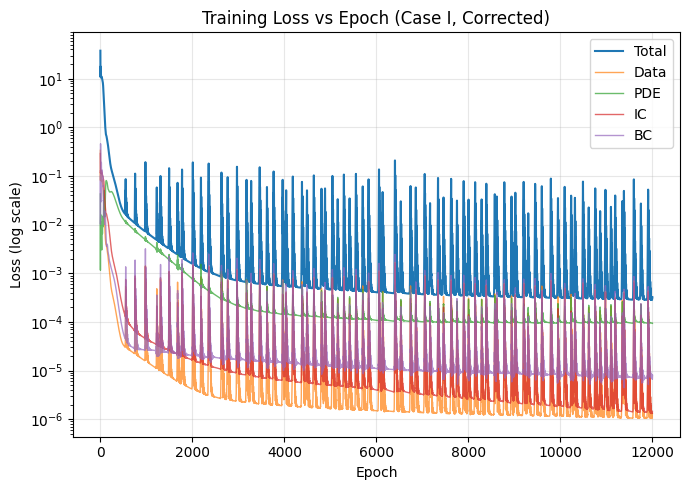

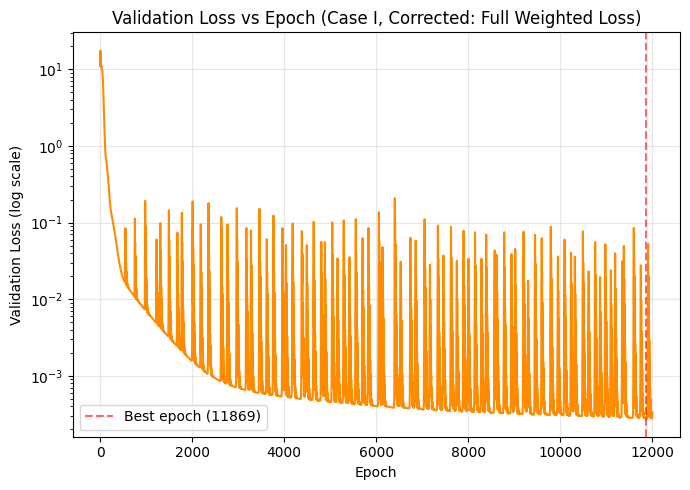

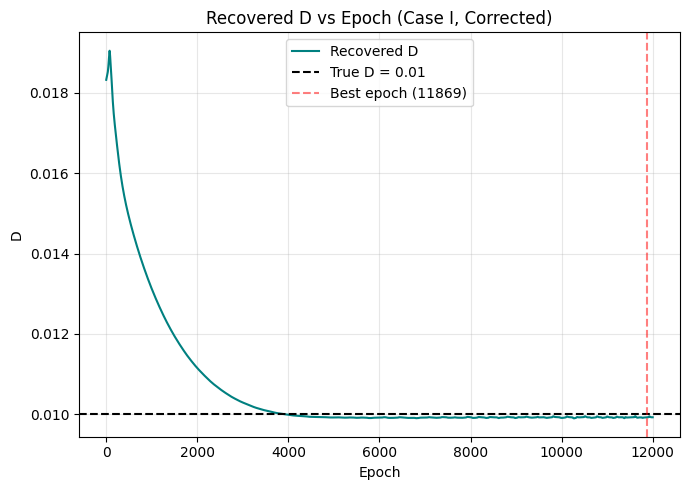

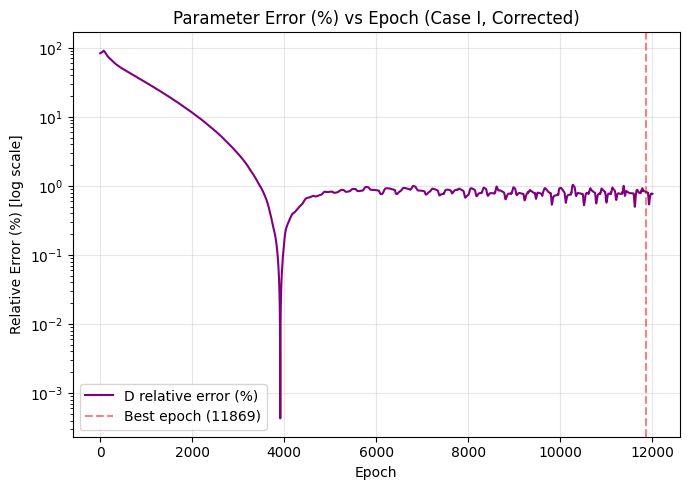

Plots 1-4 saved.


In [9]:
# ============================================================
# CELL 9: Plots — Loss Curves, D Convergence, Parameter Error
# ============================================================

epochs_range = np.arange(1, len(history["train_total"]) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["train_total"], label="Total", lw=1.5)
plt.plot(epochs_range, history["train_data"], label="Data", lw=1, alpha=0.7)
plt.plot(epochs_range, history["train_pde"], label="PDE", lw=1, alpha=0.7)
plt.plot(epochs_range, history["train_ic"], label="IC", lw=1, alpha=0.7)
plt.plot(epochs_range, history["train_bc"], label="BC", lw=1, alpha=0.7)
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("Loss (log scale)")
plt.title("Training Loss vs Epoch (Case I, Corrected)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/case1_plot1_training_loss.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["val_total"], color="darkorange", lw=1.5)
plt.axvline(best_epoch + 1, color="red", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch+1})")
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("Validation Loss (log scale)")
plt.title("Validation Loss vs Epoch (Case I, Corrected: Full Weighted Loss)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/case1_plot2_validation_loss.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["D"], color="teal", lw=1.5, label="Recovered D")
plt.axhline(D_true, color="black", linestyle="--", label=f"True D = {D_true}")
plt.axvline(best_epoch + 1, color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({best_epoch+1})")
plt.xlabel("Epoch"); plt.ylabel("D")
plt.title("Recovered D vs Epoch (Case I, Corrected)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/case1_plot3_D_convergence.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["D_error_pct"], color="purple", lw=1.5, label="D relative error (%)")
plt.axvline(best_epoch + 1, color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({best_epoch+1})")
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("Relative Error (%) [log scale]")
plt.title("Parameter Error (%) vs Epoch (Case I, Corrected)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/case1_plot4_param_error.png", dpi=150)
plt.show()

print("Plots 1-4 saved.")

In [10]:
# ============================================================
# CELL 10: Full-Field PINN Inference
# ============================================================

model.eval()

X_full, T_full = np.meshgrid(x_grid, t_grid)
x_full_flat = X_full.reshape(-1, 1)
t_full_flat = T_full.reshape(-1, 1)

x_full_t = torch.tensor(x_full_flat, dtype=torch.float32, device=device)
t_full_t = torch.tensor(t_full_flat, dtype=torch.float32, device=device)

batch_size = 20000
preds = []
with torch.no_grad():
    for i in range(0, x_full_t.shape[0], batch_size):
        u_pred_batch = model(x_full_t[i:i+batch_size], t_full_t[i:i+batch_size])
        preds.append(u_pred_batch.cpu().numpy())

U_pred_grid = np.concatenate(preds, axis=0).reshape(Nt, Nx)
Abs_Error_grid = np.abs(U_pred_grid - U_grid)

print("PINN full-field prediction computed.")
print(f"Max absolute error: {Abs_Error_grid.max():.6e}")
print(f"Mean absolute error: {Abs_Error_grid.mean():.6e}")

PINN full-field prediction computed.
Max absolute error: 8.326156e-03
Mean absolute error: 7.024879e-04


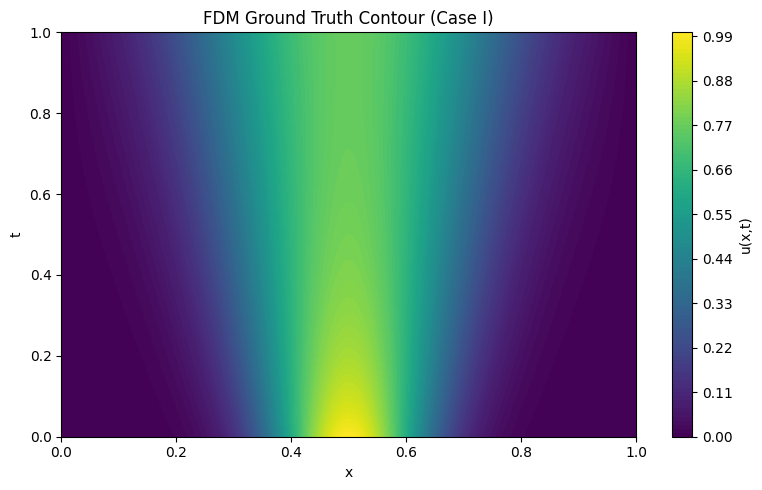

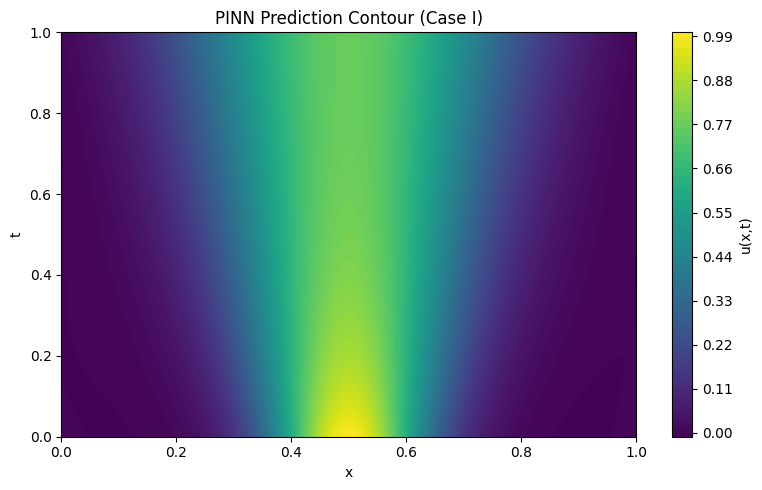

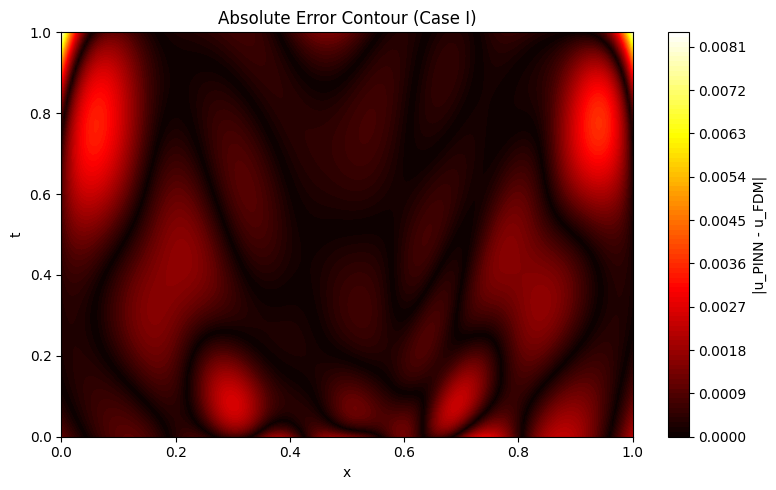

Contour plots saved.


In [11]:
# ============================================================
# CELL 11: Contour Plots — FDM, PINN, Absolute Error
# ============================================================

plt.figure(figsize=(8, 5))
cp1 = plt.contourf(X_full, T_full, U_grid, levels=100, cmap="viridis")
plt.colorbar(cp1, label="u(x,t)")
plt.xlabel("x"); plt.ylabel("t")
plt.title("FDM Ground Truth Contour (Case I)")
plt.tight_layout()
plt.savefig("/content/case1_plot5_fdm_contour.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
cp2 = plt.contourf(X_full, T_full, U_pred_grid, levels=100, cmap="viridis")
plt.colorbar(cp2, label="u(x,t)")
plt.xlabel("x"); plt.ylabel("t")
plt.title("PINN Prediction Contour (Case I)")
plt.tight_layout()
plt.savefig("/content/case1_plot6_pinn_contour.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
cp3 = plt.contourf(X_full, T_full, Abs_Error_grid, levels=100, cmap="hot")
plt.colorbar(cp3, label="|u_PINN - u_FDM|")
plt.xlabel("x"); plt.ylabel("t")
plt.title("Absolute Error Contour (Case I)")
plt.tight_layout()
plt.savefig("/content/case1_plot7_abs_error_contour.png", dpi=150)
plt.show()

print("Contour plots saved.")

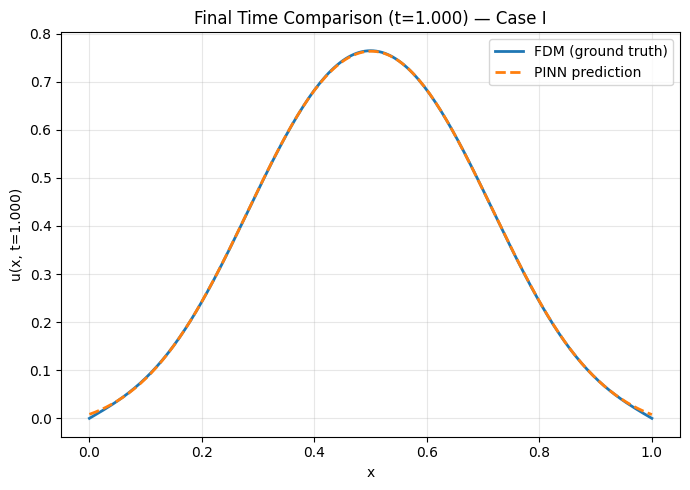

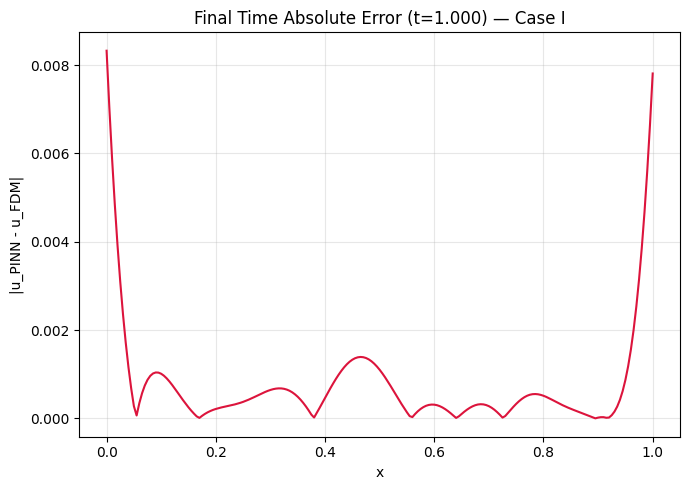

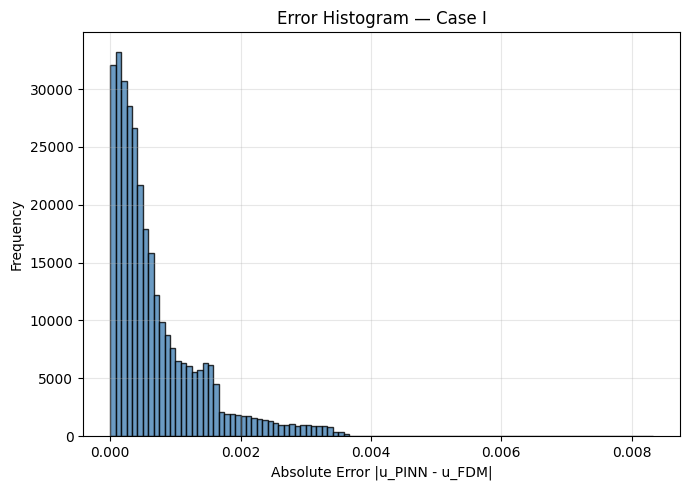

Final-time and histogram plots saved.


In [12]:
# ============================================================
# CELL 12: Final Time Comparison, Error, and Histogram
# ============================================================

final_t_idx = -1
final_t_value = t_grid[final_t_idx]

u_fdm_final = U_grid[final_t_idx, :]
u_pinn_final = U_pred_grid[final_t_idx, :]
error_final = np.abs(u_pinn_final - u_fdm_final)

plt.figure(figsize=(7, 5))
plt.plot(x_grid, u_fdm_final, label="FDM (ground truth)", lw=2)
plt.plot(x_grid, u_pinn_final, "--", label="PINN prediction", lw=2)
plt.xlabel("x"); plt.ylabel(f"u(x, t={final_t_value:.3f})")
plt.title(f"Final Time Comparison (t={final_t_value:.3f}) — Case I")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/case1_plot8_final_time_comparison.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(x_grid, error_final, color="crimson", lw=1.5)
plt.xlabel("x"); plt.ylabel("|u_PINN - u_FDM|")
plt.title(f"Final Time Absolute Error (t={final_t_value:.3f}) — Case I")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/case1_plot9_final_time_error.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(Abs_Error_grid.flatten(), bins=100, color="steelblue", edgecolor="black", alpha=0.8)
plt.xlabel("Absolute Error |u_PINN - u_FDM|")
plt.ylabel("Frequency")
plt.title("Error Histogram — Case I")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/case1_plot10_error_histogram.png", dpi=150)
plt.show()

print("Final-time and histogram plots saved.")

In [13]:
# ============================================================
# CELL 13: Final Metrics Report — Case I (Corrected)
# ============================================================

error_field = U_pred_grid - U_grid
RMSE = np.sqrt(np.mean(error_field**2))
MAE = np.mean(np.abs(error_field))
Relative_L2 = np.linalg.norm(error_field) / np.linalg.norm(U_grid)
Max_Abs_Error = np.max(np.abs(error_field))
Mean_Error = np.mean(error_field)
Std_Error = np.std(error_field)

D_rel_error_pct = abs(D_final - D_true) / D_true * 100.0

print("=" * 65)
print("FINAL METRICS REPORT — Inverse PINN (Fisher-KPP, Case I, Corrected)")
print("D Unknown, r Fixed = 1.0")
print("=" * 65)
print(f"{'True D':<30}: {D_true}")
print(f"{'Recovered D':<30}: {D_final:.6f}")
print(f"{'Relative Error in D (%)':<30}: {D_rel_error_pct:.6f}")
print("-" * 65)
print(f"{'RMSE':<30}: {RMSE:.6e}")
print(f"{'MAE':<30}: {MAE:.6e}")
print(f"{'Relative L2 Error':<30}: {Relative_L2:.6e}")
print(f"{'Maximum Absolute Error':<30}: {Max_Abs_Error:.6e}")
print(f"{'Mean Error':<30}: {Mean_Error:.6e}")
print(f"{'Standard Deviation of Error':<30}: {Std_Error:.6e}")
print("=" * 65)
print(f"Best epoch (restored model): {best_epoch + 1}")
print(f"Total epochs run: {epoch + 1}")
print("=" * 65)

metrics_dict = {
    "true_D": [D_true], "recovered_D": [D_final], "D_rel_error_pct": [D_rel_error_pct],
    "RMSE": [RMSE], "MAE": [MAE], "Relative_L2_Error": [Relative_L2],
    "Max_Abs_Error": [Max_Abs_Error], "Mean_Error": [Mean_Error], "Std_Error": [Std_Error],
    "best_epoch": [best_epoch + 1], "total_epochs_run": [epoch + 1]
}
metrics_df = pd.DataFrame(metrics_dict)
metrics_df.to_csv("/content/case1_final_metrics_report.csv", index=False)
print("\nMetrics saved to /content/case1_final_metrics_report.csv")

FINAL METRICS REPORT — Inverse PINN (Fisher-KPP, Case I, Corrected)
D Unknown, r Fixed = 1.0
True D                        : 0.01
Recovered D                   : 0.009919
Relative Error in D (%)       : 0.810197
-----------------------------------------------------------------
RMSE                          : 1.011638e-03
MAE                           : 7.024879e-04
Relative L2 Error             : 2.398049e-03
Maximum Absolute Error        : 8.326156e-03
Mean Error                    : -1.370946e-04
Standard Deviation of Error   : 1.002306e-03
Best epoch (restored model): 11869
Total epochs run: 12000

Metrics saved to /content/case1_final_metrics_report.csv


In [14]:
# ============================================================
# Reusable Function: recover_D_from_dataset()
# (Direct analog of recover_r_from_dataset(), for D-unknown case)
# ============================================================

def recover_D_from_dataset(
    csv_path,
    r_fixed=1.0,                  # known/fixed reaction coefficient
    D_true=None,                  # optional, only used for reporting error metrics
    ic_func=None,                 # optional custom IC function; defaults to Gaussian pulse
    N_data=10000,
    N_f=10000,
    N_ic=200,
    N_bc=200,
    layers=[2, 50, 50, 50, 50, 50, 50, 50, 1],
    logD_init=-4.0,
    lr_network=1e-3,
    lr_D=5e-4,
    w_data=100.0,
    w_pde=1.0,
    w_ic=10.0,
    w_bc=10.0,
    epochs=12000,
    patience=2000,
    min_delta=1e-8,
    seed=42,
    verbose_every=1000,
    device=device
):
    """
    End-to-end inverse PINN pipeline: loads an FDM dataset (columns x, t, u),
    trains a PINN to recover the unknown diffusion coefficient D in the
    Fisher-KPP equation u_t = D*u_xx + r*u*(1-u), with r fixed/known.

    Returns
    -------
    result : dict containing:
        'model'          : trained PINN_D (best validation checkpoint restored)
        'D_recovered'    : float, final recovered D
        'D_true'         : float or None, the supplied ground truth (if given)
        'D_rel_error_pct': float or None
        'history'        : dict of per-epoch logs (train/val losses, D, D_error_pct)
        'best_epoch'     : int
        'metrics'        : dict of full-grid RMSE/MAE/RelL2/MaxErr/MeanErr/StdErr
        'grids'          : dict with x_grid, t_grid, U_grid (FDM), U_pred_grid (PINN)
    """
    np.random.seed(seed)
    torch.manual_seed(seed)

    # ---------------------------
    # 1. Load and reshape dataset
    # ---------------------------
    df_local = pd.read_csv(csv_path)
    x_grid_l = np.sort(df_local["x"].unique())
    t_grid_l = np.sort(df_local["t"].unique())
    Nx_l, Nt_l = len(x_grid_l), len(t_grid_l)

    df_sorted_l = df_local.sort_values(by=["t", "x"]).reset_index(drop=True)
    U_grid_l = df_sorted_l["u"].values.reshape(Nt_l, Nx_l)

    nonzero_frac = (df_local["u"] != 0).mean()
    if nonzero_frac < 0.3:
        print(f"WARNING: only {nonzero_frac*100:.1f}% of u values are nonzero. "
              f"Check that this dataset's FDM time-stepping ran correctly.")

    if ic_func is None:
        ic_func = lambda x: np.exp(-50 * (x - 0.5)**2)

    ic_check = np.max(np.abs(U_grid_l[0, :] - ic_func(x_grid_l)))
    print(f"[{os.path.basename(csv_path)}] Grid: Nx={Nx_l}, Nt={Nt_l} | "
          f"IC max diff: {ic_check:.3e} | nonzero u fraction: {nonzero_frac:.4f}")

    # ---------------------------
    # 2. Sample data / collocation / IC / BC points
    # ---------------------------
    data_sample_l = df_local.sample(n=N_data, random_state=seed).reset_index(drop=True)
    X_data_l = data_sample_l[["x", "t"]].values
    U_data_l = data_sample_l[["u"]].values
    X_tr, X_va, U_tr, U_va = train_test_split(X_data_l, U_data_l, test_size=0.20, random_state=seed)

    x_tr_t = torch.tensor(X_tr[:, 0:1], dtype=torch.float32, device=device)
    t_tr_t = torch.tensor(X_tr[:, 1:2], dtype=torch.float32, device=device)
    u_tr_t = torch.tensor(U_tr, dtype=torch.float32, device=device)
    x_va_t = torch.tensor(X_va[:, 0:1], dtype=torch.float32, device=device)
    t_va_t = torch.tensor(X_va[:, 1:2], dtype=torch.float32, device=device)
    u_va_t = torch.tensor(U_va, dtype=torch.float32, device=device)

    x_f_l = np.random.uniform(0, 1, (N_f, 1))
    t_f_l = np.random.uniform(1e-4, 1, (N_f, 1))
    x_f_t = torch.tensor(x_f_l, dtype=torch.float32, device=device, requires_grad=True)
    t_f_t = torch.tensor(t_f_l, dtype=torch.float32, device=device, requires_grad=True)

    x_ic_l = np.linspace(0, 1, N_ic).reshape(-1, 1)   # deterministic, corrected
    t_ic_l = np.zeros_like(x_ic_l)
    u_ic_target_l = ic_func(x_ic_l)
    x_ic_t = torch.tensor(x_ic_l, dtype=torch.float32, device=device)
    t_ic_t = torch.tensor(t_ic_l, dtype=torch.float32, device=device)
    u_ic_target_t = torch.tensor(u_ic_target_l, dtype=torch.float32, device=device)

    t_bc_l = np.random.uniform(0, 1, (N_bc, 1))       # N_bc=200, corrected
    x_left_t = torch.tensor(np.zeros_like(t_bc_l), dtype=torch.float32, device=device)
    x_right_t = torch.tensor(np.ones_like(t_bc_l), dtype=torch.float32, device=device)
    t_bc_t = torch.tensor(t_bc_l, dtype=torch.float32, device=device)
    u_bc_target_t = torch.zeros((N_bc, 1), dtype=torch.float32, device=device)

    # ---------------------------
    # 3. Fresh model + optimizer (D unknown, r fixed)
    # ---------------------------
    model_l = PINN_D(layers=layers, logD_init=logD_init).to(device)
    network_params_l = []
    for layer in model_l.linears:
        network_params_l += list(layer.parameters())
    optimizer_l = torch.optim.Adam([
        {"params": network_params_l, "lr": lr_network},
        {"params": [model_l.logD], "lr": lr_D}
    ])

    # ---------------------------
    # 4. Training loop with early stopping (full weighted validation loss)
    # ---------------------------
    history_l = {"train_total": [], "val_total": [], "D": [], "D_error_pct": []}
    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None
    patience_ctr = 0

    start_time = time.time()
    for epoch in range(epochs):
        model_l.train()
        optimizer_l.zero_grad()
        L_total, *_ = total_loss(
            model_l, x_tr_t, t_tr_t, u_tr_t, x_f_t, t_f_t,
            x_ic_t, t_ic_t, u_ic_target_t, x_left_t, x_right_t, t_bc_t, u_bc_target_t,
            r=r_fixed, w_data=w_data, w_pde=w_pde, w_ic=w_ic, w_bc=w_bc
        )
        L_total.backward()
        optimizer_l.step()

        model_l.eval()
        Lv_total, *_ = total_loss(
            model_l, x_va_t, t_va_t, u_va_t, x_f_t, t_f_t,
            x_ic_t, t_ic_t, u_ic_target_t, x_left_t, x_right_t, t_bc_t, u_bc_target_t,
            r=r_fixed, w_data=w_data, w_pde=w_pde, w_ic=w_ic, w_bc=w_bc
        )

        D_current = model_l.D.item()
        D_err_pct = (abs(D_current - D_true) / D_true * 100.0) if D_true is not None else None

        history_l["train_total"].append(L_total.item())
        history_l["val_total"].append(Lv_total.item())
        history_l["D"].append(D_current)
        history_l["D_error_pct"].append(D_err_pct)

        current_val = Lv_total.item()
        if current_val < best_val_loss - min_delta:
            best_val_loss = current_val
            best_epoch = epoch
            best_state = copy.deepcopy(model_l.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1

        if (epoch + 1) % verbose_every == 0 or epoch == 0:
            err_str = f"{D_err_pct:.4f}%" if D_err_pct is not None else "N/A"
            print(f"  Epoch {epoch+1:5d}/{epochs} | Train: {L_total.item():.4e} | "
                  f"Val: {current_val:.4e} | D={D_current:.6f} (err {err_str}) | "
                  f"Patience {patience_ctr}/{patience}")

        if patience_ctr >= patience:
            print(f"  Early stopping at epoch {epoch+1}. Best epoch: {best_epoch+1}")
            break

    print(f"  Training finished in {time.time()-start_time:.1f}s")
    model_l.load_state_dict(best_state)
    model_l.eval()
    D_final_l = model_l.D.item()
    D_rel_err = (abs(D_final_l - D_true) / D_true * 100.0) if D_true is not None else None

    # ---------------------------
    # 5. Full-field inference + metrics
    # ---------------------------
    X_full_l, T_full_l = np.meshgrid(x_grid_l, t_grid_l)
    x_full_flat = X_full_l.reshape(-1, 1)
    t_full_flat = T_full_l.reshape(-1, 1)
    x_full_t = torch.tensor(x_full_flat, dtype=torch.float32, device=device)
    t_full_t = torch.tensor(t_full_flat, dtype=torch.float32, device=device)

    batch_size = 20000
    preds = []
    with torch.no_grad():
        for i in range(0, x_full_t.shape[0], batch_size):
            preds.append(model_l(x_full_t[i:i+batch_size], t_full_t[i:i+batch_size]).cpu().numpy())
    U_pred_grid_l = np.concatenate(preds, axis=0).reshape(Nt_l, Nx_l)

    err_field = U_pred_grid_l - U_grid_l
    metrics = {
        "RMSE": np.sqrt(np.mean(err_field**2)),
        "MAE": np.mean(np.abs(err_field)),
        "Relative_L2": np.linalg.norm(err_field) / np.linalg.norm(U_grid_l),
        "Max_Abs_Error": np.max(np.abs(err_field)),
        "Mean_Error": np.mean(err_field),
        "Std_Error": np.std(err_field),
    }

    print(f"\n  Recovered D = {D_final_l:.6f}" +
          (f"  (true={D_true}, rel error={D_rel_err:.4f}%)" if D_true is not None else ""))
    print(f"  Relative L2 Error (full grid): {metrics['Relative_L2']:.6e}")

    return {
        "model": model_l,
        "D_recovered": D_final_l,
        "D_true": D_true,
        "D_rel_error_pct": D_rel_err,
        "r_fixed": r_fixed,
        "history": history_l,
        "best_epoch": best_epoch,
        "metrics": metrics,
        "grids": {
            "x_grid": x_grid_l, "t_grid": t_grid_l,
            "U_grid": U_grid_l, "U_pred_grid": U_pred_grid_l
        }
    }


print("recover_D_from_dataset() defined and ready to use.")

recover_D_from_dataset() defined and ready to use.


In [15]:
# ============================================================
# Example Usage
# ============================================================

result_D = recover_D_from_dataset(
    csv_path="/content/FisherKPP_Inverse_PINN_Dataset.csv",
    r_fixed=1.0,
    D_true=0.01
)

print("\n" + "="*50)
print(f"Recovered D = {result_D['D_recovered']:.6f}  "
      f"(error = {result_D['D_rel_error_pct']:.4f}%)")
print("="*50)

# For a brand-new dataset where you DON'T know D_true:
# result_new = recover_D_from_dataset(csv_path="/content/new_dataset.csv", r_fixed=1.0)
# print("Recovered D:", result_new["D_recovered"])

[FisherKPP_Inverse_PINN_Dataset.csv] Grid: Nx=201, Nt=1600 | IC max diff: 3.727e-06 | nonzero u fraction: 0.9900
  Epoch     1/12000 | Train: 3.7707e+01 | Val: 1.6082e+01 | D=0.018325 (err 83.2480%) | Patience 0/2000
  Epoch  1000/12000 | Train: 6.7870e-03 | Val: 6.8384e-03 | D=0.013118 (err 31.1808%) | Patience 0/2000
  Epoch  2000/12000 | Train: 1.3697e-03 | Val: 1.3576e-03 | D=0.011154 (err 11.5374%) | Patience 0/2000
  Epoch  3000/12000 | Train: 1.5462e-03 | Val: 9.8713e-04 | D=0.010298 (err 2.9828%) | Patience 77/2000
  Epoch  4000/12000 | Train: 9.9060e-02 | Val: 1.1963e-01 | D=0.009981 (err 0.1888%) | Patience 33/2000
  Epoch  5000/12000 | Train: 7.2926e-04 | Val: 1.0871e-03 | D=0.009914 (err 0.8633%) | Patience 210/2000
  Epoch  6000/12000 | Train: 4.0706e-04 | Val: 3.9946e-04 | D=0.009904 (err 0.9553%) | Patience 2/2000
  Epoch  7000/12000 | Train: 3.7265e-04 | Val: 3.6562e-04 | D=0.009909 (err 0.9141%) | Patience 1/2000
  Epoch  8000/12000 | Train: 3.4515e-04 | Val: 3.3905e-0